# Chapter 13 example: outer optimization with an inner partition function

Structured scientific design often places inference inside optimization. We use a four-node Ising model whose local fields $h$ can be adjusted under a quadratic budget. The inner problem computes exact magnetizations

$$
m_a(J,h)=\frac{\partial \log Z(J,h)}{\partial h_a},
$$

and the outer problem chooses $h$ to reduce a weighted observable $\rho^T m$.

The example is small enough for exact enumeration, but its nested structure is representative of control, experimental design, and inverse problems.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

-3.032474268917835 [-0.34443708 -0.37466317 -0.35246012 -0.32674528] 0.7000000000000431


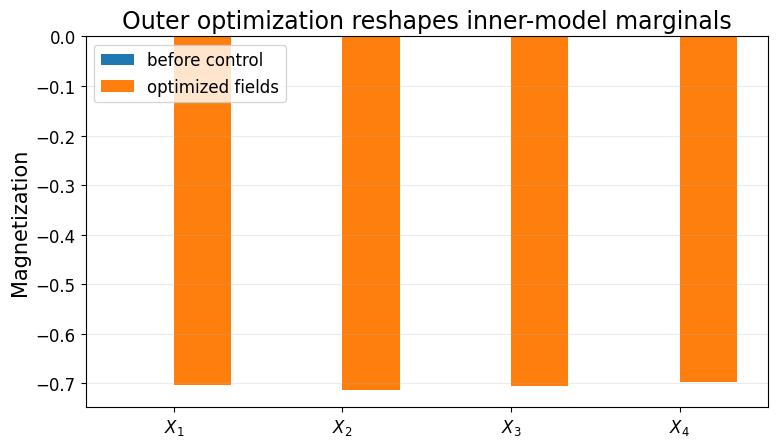

In [2]:
n=4; edges=[(0,1),(1,2),(2,3),(3,0)]; J={e:.55 for e in edges}; rho=np.array([1.,1.4,1.1,.8]); states=np.array(list(product([-1,1],repeat=n)),float)
def stats(h):
 lw=np.array([sum(J[e]*x[e[0]]*x[e[1]] for e in edges)+h@x for x in states]); pp=np.exp(lw-lw.max()); pp/=pp.sum(); return np.log(np.exp(lw-lw.max()).sum())+lw.max(),pp@states
def objective(h): return rho@stats(h)[1]
budget=0.7
cons={'type':'ineq','fun':lambda h: budget**2-h@h}
res=minimize(objective,np.zeros(n),method='SLSQP',constraints=cons,options={'ftol':1e-12,'maxiter':1000}); print(res.fun,res.x,np.linalg.norm(res.x));
base=stats(np.zeros(n))[1]; opt=stats(res.x)[1]
fig,ax=plt.subplots(figsize=(8,4.7)); x=np.arange(n); w=.34; ax.bar(x-w/2,base,w,label='before control'); ax.bar(x+w/2,opt,w,label='optimized fields'); ax.set_xticks(x,[rf'$X_{i+1}$' for i in range(n)]); ax.set_ylabel('Magnetization'); ax.set_title('Outer optimization reshapes inner-model marginals'); ax.legend(); ax.grid(axis='y',alpha=.25); fig.tight_layout(); save_figure(fig,'ch13_04_controlled_marginals'); plt.show()

In [3]:
# verify derivative identity for log Z
h0=res.x; eps=1e-5; logZ,m=stats(h0); fd=[]
for a in range(n):
 d=np.zeros(n); d[a]=eps; fd.append((stats(h0+d)[0]-stats(h0-d)[0])/(2*eps))
print(pd.DataFrame({'exact magnetization':m,'finite-difference d logZ/dh':fd}))
assert np.allclose(m,fd,atol=1e-7)

   exact magnetization  finite-difference d logZ/dh
0            -0.702487                    -0.702487
1            -0.712399                    -0.712399
2            -0.705219                    -0.705219
3            -0.696109                    -0.696109


## Exercises

1. Change the budget and trace the Pareto curve between control effort and the observable $\rho^Tm$.
2. Optimize selected couplings $J_{ab}$ rather than fields. Use $\partial\log Z/\partial J_{ab}=\mathbb{E}[X_aX_b]$.
3. **Challenge.** Replace exact enumeration by Bethe or Gaussian-like approximate inference and study how inference error propagates into the outer optimum.